<a href="https://colab.research.google.com/github/acalixtroq/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

    En el dataset `users`, faltan datos en `city` (11.72%) y en `churn_date` (88.35%). En el dataset `usage`, hay nulos en `date` (0.12%), `duration` (55.19%) y `length` (44.74%).

- Indica qué harías: ¿imputar, eliminar, ignorar?

    1. Dataset `users`:

    - `city` (11.72%): Investigar e imputar. Al estar entre el 5% y 30%, sugiero rellenar los nulos con "Desconocido" o la moda para no perder esos registros en el análisis.

    - `churn_date` (88.35%): Ignorar (dejar como nulo). Aunque supera el 80% y la regla general diría eliminarla, por lógica de negocio, un nulo aquí significa que el usuario no ha cancelado su plan (sigue activo).

    2. Dataset `usage`:

    - `date` (0.12%): Eliminar o imputar de forma simple. Al ser menor al 5% (solo 50 filas), su impacto es minúsculo; se pueden eliminar esos registros o deducir la fecha si es posible.

    - `duration` (55.19%) y `length` (44.74%): Investigar para imputar con 0. La alta falta de datos se debe a la naturaleza de la columna `type`: las llamadas generan `duration` (minutos) pero los datos/mensajes generan `length` (MB/caracteres). Sugiero rellenar con 0 donde el servicio no aplique.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador único y secuencial que va desde el valor 10,000 hasta el 13,999. Dado que hay exactamente 4,000 registros, podemos deducir que no hay valores duplicados ni faltantes en la secuencia. Cabe destacar que calcular estadísticas (como la media o los cuartiles) sobre identificadores no tiene utilidad analítica.
- La columna `age` presenta un problema severo de calidad de datos. Tiene un valor mínimo de -999.0, lo cual es lógicamente imposible para una edad y claramente representa un error de captura o un código de valor nulo disfrazado. Este valor atípico (outlier) está distorsionando drásticamente el promedio (bajándolo a 33.7) y la desviación estándar, si consideramos que la mediana real está en 47 años. Será necesario limpiar o filtrar estos valores atípicos antes de analizar esta variable.

In [ ]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son simples identificadores (llave primaria y foránea respectivamente). `id` es un índice secuencial perfecto del 1 al 40,000, y `user_id` se mantiene dentro del rango de usuarios previamente visto (10,000 a 13,999). Calcular métricas estadísticas como promedios o percentiles sobre ellas no tiene ningún sentido ni utilidad analítica.
- Las columnas `duration` y `length` tienen un conteo de datos menor a 40,000, lo que confirma la presencia de los valores nulos detectados anteriormente. Ambas tienen valores mínimos de 0.0, lo cual es normal (ej. llamadas perdidas de 0 segundos). Sin embargo, presentan posibles valores atípicos (outliers) en sus máximos: `duration` tiene registros de hasta 120 minutos, y `length` tiene un máximo extremo de 1490.0, que está exageradamente lejos de su percentil 75% (que es solo 64.0). Esto sugiere que la distribución de los datos está fuertemente sesgada a la derecha.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` muestra las principales ciudades de origen de los usuarios, pero revela un claro problema de calidad de datos: existen 96 registros en total (65 de plan Básico y 31 de Premium) donde la ciudad está registrada con el símbolo `?`. Este es un "nulo oculto" o error de captura que deberá ser tratado en la fase de limpieza (por ejemplo, reemplazándolo por un valor nulo real o por la etiqueta "Desconocido").
- La columna `plan` parece estar completamente limpia y consistente. Solo contiene las dos categorías válidas y esperadas: "Basico" y "Premium", sin errores tipográficos o categorías extrañas. Además, este conteo nos permite observar una tendencia clara de negocio: el plan "Basico" tiene una mayor cantidad de usuarios que el plan "Premium" de manera consistente en todas y cada una de las ciudades.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` se encuentra completamente limpia y bien estructurada, sin valores extraños o errores tipográficos. Contiene únicamente las dos categorías válidas: "text" (22,092 registros) y "call" (17,908 registros), que suman exactamente el total de 40,000 filas del dataset. El conteo nos revela que existe un mayor volumen de interacciones por mensajes de texto/datos en comparación con las llamadas de voz.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

    Tras la exploración de las variables, se identificaron los siguientes "sentinels" (valores usados artificialmente para rellenar vacíos):
      - Columnas Numéricas: En la columna `age` (del dataset `users`), se encontró el valor `-999.0`.
      - Columnas Categóricas: En la columna `city` (del dataset `users`), se encontró el símbolo `?`.

- ¿Qué acción tomarías?

    1. **Estandarización a Nulos reales**: La primera acción fundamental es usar la función `.replace()` de Pandas para transformar tanto el `-999.0` como el `?` al formato estándar de valores faltantes (`np.nan` o `NaN`). Si no hacemos esto, el `-999` arruinará cualquier cálculo estadístico (como la media de edad) y el `?` creará una categoría falsa.

    2. **Tratamiento (Imputación)**:
         - Para `age`: Una vez convertidos a `NaN`, sugeriría imputarlos con la mediana de la edad de los usuarios. Se prefiere la mediana sobre la media para que no se vea afectada por otros posibles valores extremos.
        - Para `city`: Al ser categórica, se puede imputar utilizando la moda (la ciudad más frecuente) o, para no alterar la distribución original, reemplazarlos por una nueva categoría explícita llamada `"Desconocido"`.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En la columna `reg_date`, Los registros son muy constantes entre 2022 y 2024 (aprox. 1,320 por año). Sin embargo, considerando la restricción de que los datos llegan solo hasta 2024, se detecta un claro error de captura:
- Fechas imposibles (fuera de rango): Aparecen 40 registros en el año 2026. Dado que el dataset termina en 2024, estas fechas son "futuras" e inválidas. Es muy probable que se trate de errores tipográficos (por ejemplo, digitar '2026' en lugar de '2024' o '2022').

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En la columna `date`, se observa que todos los registros válidos (39,950) corresponden exclusivamente al año 2024.

Basaremos el análisis en estas fechas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Sí, pero únicamente en el dataset de usuarios (`users`). En la columna `reg_date`, se encontraron 40 registros con el año 2026. Dado que la regla de negocio establece que los datos están registrados solo hasta 2024, el año 2026 es una fecha "futura" e imposible (probablemente un error tipográfico).
Por el contrario, en el dataset de consumo (`usage`), la columna `date` no presenta años imposibles; el 100% de sus registros se concentra válidamente en el año 2024.

- ¿Qué harías con ellas?

Para los datos de usuarios (`users`): Recomiendo aislar las 40 filas del año 2026. Al ser un porcentaje mínimo (1% de los datos), se pueden eliminar o convertirlas a valores nulos (`NaN`) para que no distorsionen los cálculos de antigüedad o retención.

Para los datos de consumo (`usage`): No se requiere eliminar ningún registro porque no hay fechas inválidas. Sin embargo, la acción clave aquí es documentar la limitación: debemos tener en cuenta que nuestro análisis de llamadas y mensajes estará acotado únicamente a una "fotografía" del año 2024, sin poder ver el historial de consumo de 2022 o 2023.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

users['reg_date'] = np.where(
    users['reg_date'].dt.year == 2026,
    pd.NA,
    users['reg_date']
)

users['reg_date'] = pd.to_datetime(users['reg_date'])

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration por tipo:")
usage['duration'].isna().groupby(usage['type']).value_counts()

Nulos en duration por tipo:


type  duration
call  False       17908
text  True        22076
      False          16
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("Nulos en length por tipo:")
usage['length'].isna().groupby(usage['type']).value_counts()

Nulos en length por tipo:


type  length
call  True      17896
      False        12
text  False     22092
Name: length, dtype: int64

Haz doble clic aquí y escribe tu diagnostico de nulos en `duration` y `length`

- Descubrimiento: La falta de datos depende totalmente del tipo de servicio (`type`). Los nulos en `duration` solo ocurren en el servicio "text", mientras que los nulos en `length` solo ocurren en el servicio "call".

- Conclusión: Se confirma que los nulos son MAR (Missing At Random) (su ausencia se explica por otra variable observada).

- Acción y Justificación: Dejarlos como nulos. Esta ausencia refleja la lógica del negocio: una llamada se mide en minutos (`duration`) y no en megas/caracteres (`length`), y viceversa. Forzar una imputación (ej. poner ceros o promedios) falsearía los datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text' : 'sum',
    'is_call' : 'sum',
    'duration' : 'sum',
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text' : 'cant_mensajes',
    'is_call' : 'cant_llamadas',
    'duration' : 'cant_minutos_llamada',
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

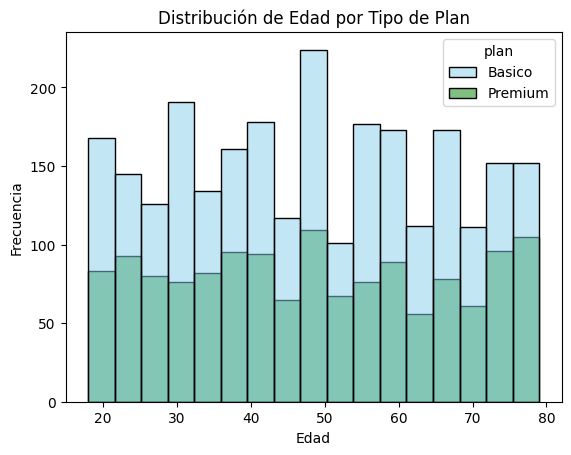

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- **Forma de la distribución**: La distribución de la edad es uniforme. No presenta una forma de campana (simétrica) ni un sesgo evidente hacia la izquierda o la derecha. Esto indica que la frecuencia de usuarios se mantiene constante a lo largo de casi todos los bloques de edad (desde los 20 hasta cerca de los 80 años).
- **Insight sobre el plan**: La proporción entre los usuarios del plan Básico (azul) y Premium (verde) parece mantenerse relativamente estable en todos los grupos de edad. No existe un patrón claro que indique que un plan específico sea predominantemente preferido por un rango de edad particular.

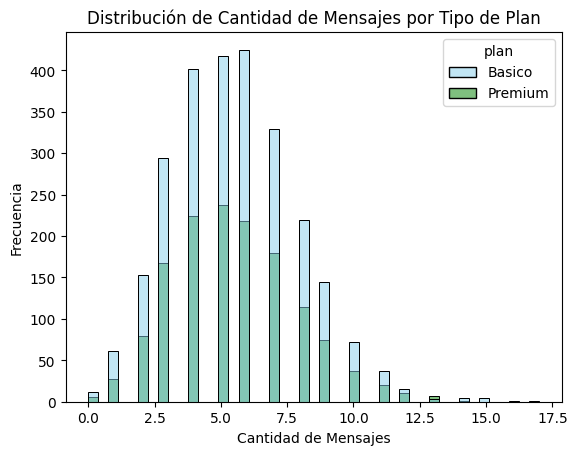

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- **Forma de la distribución**: La gráfica muestra una distribución con un ligero sesgo a la derecha (asimetría positiva). Aunque tiene un pico claro en el centro que le da un aspecto acampanado, la "cola" de la gráfica se extiende más hacia los valores altos en la derecha (entre 10 y 17.5 mensajes).
- **Insight sobre el plan y la variable**: Independientemente del tipo de plan (Básico o Premium), el comportamiento de los usuarios es casi idéntico. En ambos planes, la mayor proporción de usuarios tiende a enviar entre 4 y 7 mensajes. La frecuencia disminuye considerablemente después de los 10 mensajes. En conclusión, no existe un patrón diferenciado en la cantidad de mensajes enviados que esté directamente ligado al tipo de plan contratado.

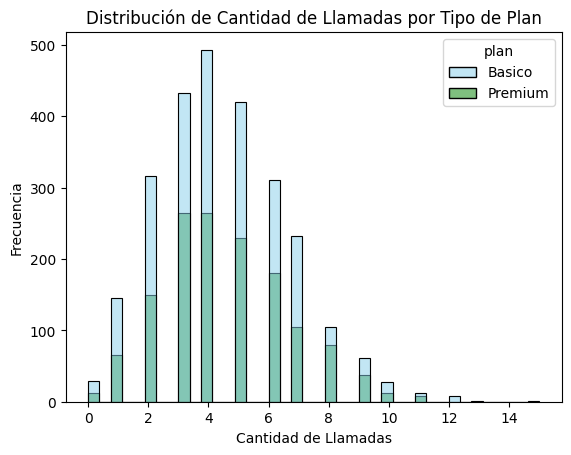

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- **Forma de la distribución**: Al igual que el gráfico anterior, esta distribución está sesgada a la derecha (asimetría positiva). La gran mayoría de los datos se agrupa en los valores más bajos (a la izquierda), formando un pico prominente, y presenta una "cola" que se extiende hacia los valores más altos (hacia la derecha, superando las 10 llamadas).
- **Insight sobre el plan y la variable**: No existe un comportamiento diferenciado entre los planes. Tanto los usuarios del plan Básico como los del Premium muestran una tendencia idéntica: la mayor proporción de clientes realiza entre 2 y 5 llamadas en total. A partir de las 6 llamadas, la frecuencia comienza a caer drásticamente de manera uniforme para ambos grupos, siendo muy raro encontrar usuarios que superen las 10 llamadas.

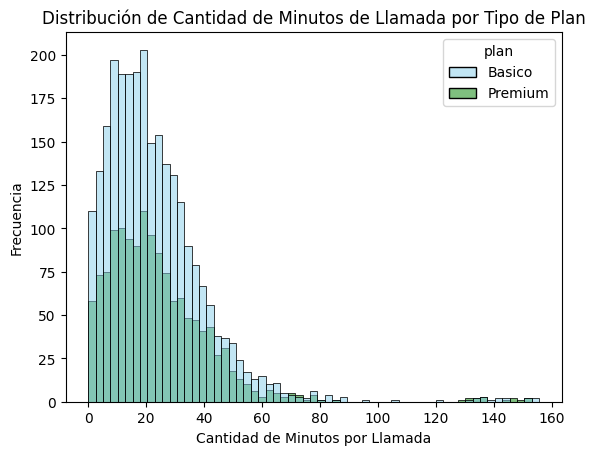

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Cantidad de Minutos por Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- **Forma de la distribución**: La gráfica presenta una clara distribución sesgada a la derecha (asimetría positiva). La gran mayoría de las frecuencias se acumulan en el lado izquierdo (valores más bajos), dejando una "cola" larga y plana que se extiende hacia los valores más altos en la derecha.
- **Insight sobre el plan y la variable**: El patrón de consumo de minutos es bastante similar en ambos planes. La mayor proporción de usuarios, tanto del plan Básico como del Premium, tiende a acumular entre 10 y 30 minutos por llamada. La frecuencia disminuye progresivamente a medida que los minutos aumentan. Sin embargo, un detalle a destacar es que en la cola extrema derecha de la gráfica (entre los 130 y 160 minutos), se observa una ligera presencia exclusiva de usuarios del plan Premium. Esto indica que los casos atípicos de llamadas extremadamente largas pertenecerían a este grupo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

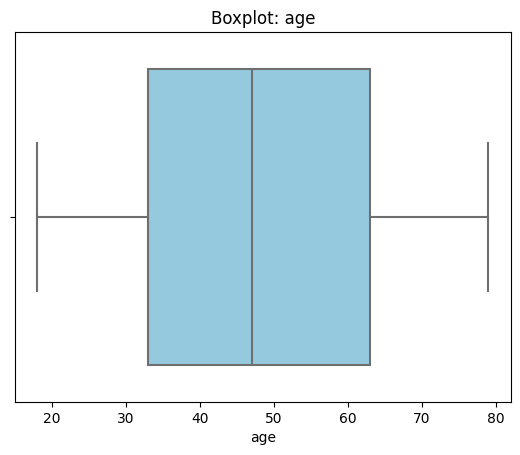

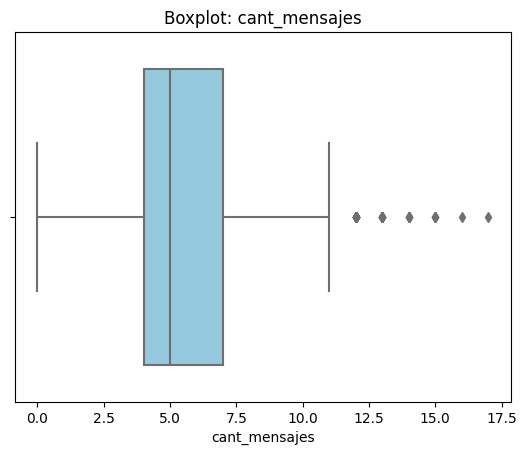

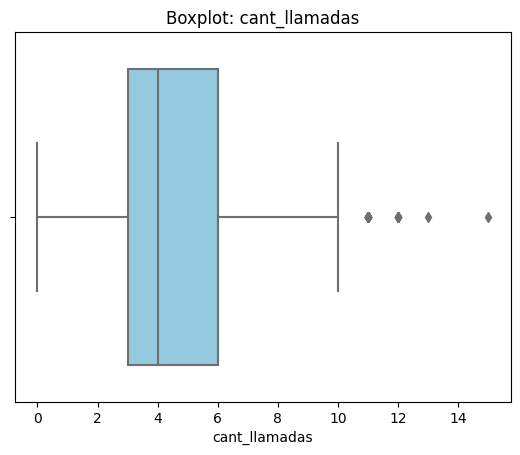

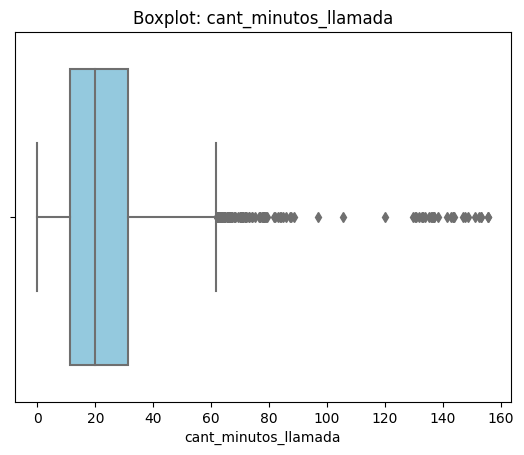

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- **Age**: No presenta outliers. Todos los valores se encuentran contenidos dentro de los "bigotes" del gráfico, lo que indica que no hay edades extremas o anómalas registradas en los datasets.
- **cant_mensajes**: Presenta outliers superiores. Se observan puntos individuales más allá del límite superior del bigote (a partir de los 11 o 12 mensajes aproximadamente), lo que refleja un grupo minoritario de usuarios con una alta frecuencia de envío.
- **cant_llamadas**: Presenta outliers superiores. Existen valores atípicos marcados a la derecha del gráfico (por encima de las 10 llamadas). Esto señala la presencia de usuarios que realizan un número de llamadas inusualmente alto en comparación con la distribución general.
- **cant_minutos_llamada**: Presenta una cantidad significativa de outliers superiores. A diferencia de las otras variables, aquí se observa una línea densa de puntos que superan el límite superior (aproximadamente a partir de los 60 minutos) y se extienden hasta casi los 160 minutos. Esto demuestra claramente la existencia de un segmento de power users (usuarios de uso intensivo) en el registro de llamadas.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("Cálculo de Límites Superiores (IQR) para Outliers:\n")

for col in columnas_limites:
    # 1. Calcular el Cuartil 1 (Q1) y el Cuartil 3 (Q3)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    # 2. Calcular el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1

    # 3. Calcular el límite superior
    limite_superior = Q3 + 1.5 * IQR

    # 4. (Opcional pero recomendado) Contar cuántos outliers hay
    cantidad_outliers = (user_profile[col] > limite_superior).sum()

    # Mostrar resultados
    print(f"--- Variable: {col} ---")
    print(f"Límite Superior: {limite_superior}")
    print(f"Cantidad de usuarios atípicos: {cantidad_outliers}")
    print("-" * 30)


Cálculo de Límites Superiores (IQR) para Outliers:

--- Variable: cant_mensajes ---
Límite Superior: 11.5
Cantidad de usuarios atípicos: 46
------------------------------
--- Variable: cant_llamadas ---
Límite Superior: 10.5
Cantidad de usuarios atípicos: 30
------------------------------
--- Variable: cant_minutos_llamada ---
Límite Superior: 61.8575
Cantidad de usuarios atípicos: 109
------------------------------


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
    - **Mantener los outliers**: El valor máximo registrado es de 17 mensajes (frente a un límite superior de 11.5). En el contexto del uso de telefonía, enviar 17 mensajes es una acción completamente normal y realista, no un error del sistema. Además, los 46 usuarios atípicos representan apenas alrededor del 1.1% del total de los datos (3999 registros). Eliminarlos significaría borrar datos válidos de clientes que simplemente son un poco más activos que el promedio.

- cant_llamadas: mantener o no outliers, porqué?
    - **Mantener los outliers**: Al igual que con los mensajes, el valor máximo es de 15 llamadas (con un límite de 10.5). Hacer 15 llamadas en un periodo determinado es un comportamiento de usuario perfectamente factible. Solo hay 30 registros atípicos (menos del 1%). Borrar estos registros alteraría artificialmente la realidad de la base de usuarios, ocultando a aquellos que más utilizan el servicio de voz.

- cant_minutos_llamada: mantener o no outliers, porqué?
    - **Mantener los outliers**: Aunque esta variable tiene la mayor cantidad de outliers (109 usuarios) y el límite superior marca ~61.85 minutos, el valor máximo es de 155.69 minutos (poco más de dos horas y media). Este es un volumen de llamadas totalmente normal para un usuario intensivo o de negocios. Si recordamos los histogramas anteriores, estos consumos extremos suelen concentrarse en los usuarios del plan Premium. No hay que eliminar estos datos, perderíamos la capacidad de analizar el comportamiento que justifica exactamente por qué esos clientes contratan (y pagan) el plan más caro.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

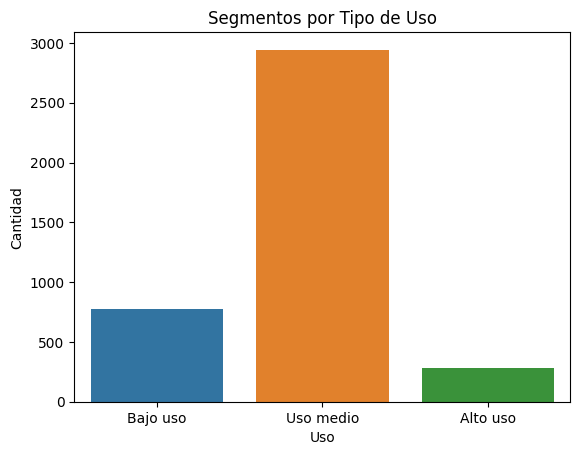

In [ ]:
# Definimos el orden lógico que queremos mostrar
orden_logico = ['Bajo uso', 'Uso medio', 'Alto uso']

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=orden_logico)
plt.title('Segmentos por Tipo de Uso')
plt.xlabel('Uso')
plt.ylabel('Cantidad')

plt.show()

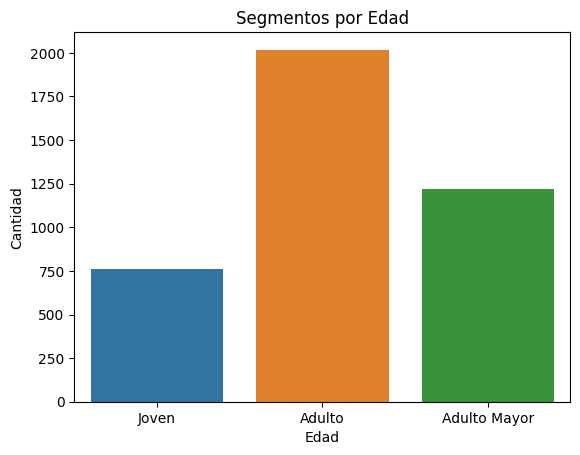

In [ ]:
# Definimos el orden lógico que queremos mostrar
orden_logico = ['Joven', 'Adulto', 'Adulto Mayor']

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=orden_logico)
plt.title('Segmentos por Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En el dataset de usuarios, la columna de edad presentó valores imposibles de -999.0 que distorsionaban las estadísticas.
- La variable de ciudad contenía un 11.72% de valores nulos y 96 registros ocultos bajo el símbolo '?'.
- Se detectaron 40 registros con fechas futuras (año 2026) en la columna de registro, lo cual era imposible dado que el alcance del análisis llega hasta 2024.
- La ausencia de datos en la duración (55.19%) y longitud (44.74%) del dataset de uso fue confirmada como Missing At Random (MAR), ya que dependía lógicamente del tipo de interacción realizada (llamada o mensaje de texto).

🔍 **Segmentos por Edad**
- Se categorizó a los usuarios en tres grandes grupos: 'Joven' (menores de 30 años), 'Adulto' (menores de 60 años) y 'Adulto Mayor' (60 años o más).
- El segmento 'Adulto' es, con gran diferencia, el mercado principal de ConnectaTel, superando los 2,000 usuarios.
- El segundo grupo en importancia es el de 'Adulto Mayor', con más de 1,250 usuarios activos.
- El segmento 'Joven' es el minoritario dentro de la base de clientes actual, manteniéndose por debajo de los 800 usuarios.

📊 **Segmentos por Nivel de Uso**
- Los clientes se clasificaron considerando sus umbrales de llamadas y mensajes en: 'Bajo uso' (menos de 5 en ambos), 'Uso medio' (menos de 10 en ambos) y 'Alto uso' (el resto).
- El comportamiento dominante absoluto es el 'Uso medio', concentrando a casi 3,000 usuarios.
- Los segmentos de 'Bajo uso' (aproximadamente 750 clientes) y 'Alto uso' (menos de 500 clientes) representan una minoría en la distribución general.
- Adicionalmente, el 64.8% de la base total de clientes prefiere el plan Básico, mientras que el 35.1% contrata el plan Premium.

➡️ **Patrones de Uso y Outliers**
- Se identificaron power users (usuarios atípicos) en todas las métricas: 46 usuarios con altos volúmenes de mensajes y 30 usuarios con alta cantidad de llamadas.
- El hallazgo más relevante reside en el consumo de voz: 109 usuarios superaron el límite superior esperado (61.85 minutos), alcanzando picos de hasta 155.69 minutos.
- Estos consumos extremos se concentran principalmente en los clientes del plan Premium.
- Estos outliers son sumamente valiosos porque representan un volumen de negocio normal para usuarios intensivos, justificando el costo y la existencia del plan más caro de la compañía.

💡 **Recomendaciones**
- Dado que la abrumadora mayoría de los clientes se concentra en el grupo 'Adulto' y presenta un 'Uso medio', ConnectaTel debería enfocar sus principales campañas de retención hacia este perfil demográfico.
- Puesto que los usuarios de uso intensivo y prolongado (power users) son quienes dan sentido a la suscripción Premium, se recomienda evaluar la creación de beneficios exclusivos (add-ons) para mantener la fidelidad de este nicho altamente rentable.
- Observando la baja penetración en el segmento 'Joven', existe una oportunidad comercial para rediseñar ofertas o paquetes de datos específicos que atraigan a las nuevas generaciones.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`